ZIELE:


## Zeitbereich & Diskretisierung

1. ABTASTRATE (Sampling Rate $f_s$) & Nyquist-Theorem

Konzept: 
- Warum führt eine Messung mit $250\,\text{Hz}$ dazu, dass nur Signale bis $125\,\text{Hz}$ exakt dargestellt werden können? Was passiert mathematisch, wenn Frequenzen darüber liegen (Aliasing)?

Praxis: 
-  künstliche $100\,\text{Hz}$-Sinuswelle erzeugen undmit verschiedenen Frequenzen abtasten

In [131]:
# Man kann es mit math machen
import math

print(math.sin(math.radians(30)))

0.49999999999999994


<img src="../screenshots/wavefunc.png" width="660" height="90"/>

<img src="../screenshots/formel.png" width="660" height="500"/>

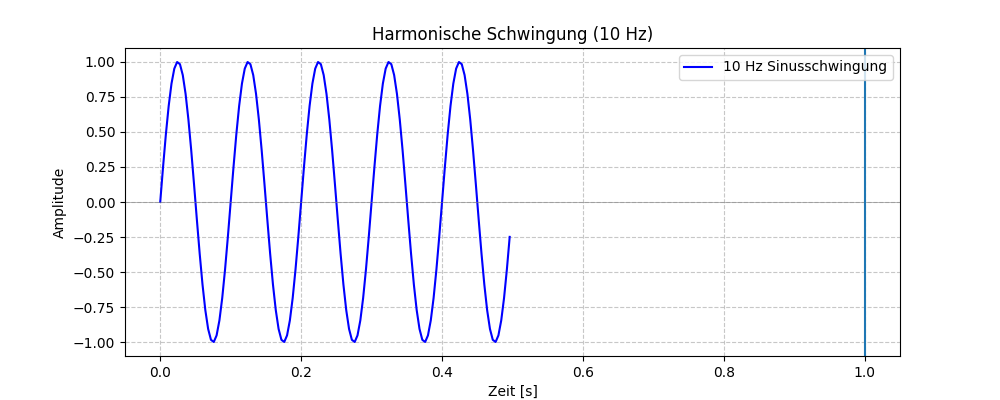

In [ ]:
import numpy as np
import matplotlib.pylab as plt

#--- Params
freq = 10 #Hz
amplitude = 1 #The units of amplitude are arbitrary, usually chosen so
# 1.0 corresponds to the maximum input
dauer = 0.5
abtastrate = 250 # Hz

# np.linspace(start, stop, num= ): 
# return evenly spaced numbers over a specified interval
t = np.linspace(0, dauer, int(abtastrate * dauer), endpoint=False)

# Schwingung berechnen (y)
#
# sin() erwartet Arg in Radiant (Winkel im Bogenmass)
# 1 vollst. Schwingung = 2pi (1 Umdrehung)
y = amplitude * np.sin(2 * np.pi * freq * t)


plt.figure(figsize=(10, 4))
plt.plot(t, y, label=f"{freq} Hz Sinusschwingung", color="b")
plt.title(f"Harmonische Schwingung ({freq} Hz)")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True, linestyle="--", alpha=0.7)
plt.axhline(0, color="grey", linewidth=0.4)
plt.axvline(1)
plt.legend(loc="upper right")
plt.show()

einen (Resonate & Fire) neuron implementieren der in einem EEG Signal bestimmte Frequenzen erkennen kann
ich wurde Augen zu Signal ausprobieren und versuchen da 10Hz zu erkennen

- 10Hz, 10.5Hz, 11Hz 
- w = 2*pi*f
- lambda = e^(b+iw)*delta_t

delta_t = 1 \ Abtastrate

![WARUM SIEHT ES SO KOMISCH AUS](../screenshots/rf_formel.png)

In [133]:
# y sind die Werte der Welle
import cmath

def get_w(freq):
    return (2 * math.pi  * freq)

def get_lambda(w):
    daempfung = -3
    delta_t = 1 / abtastrate  
    return (cmath.exp (complex(daempfung, w)*delta_t))

def ampl(z):
    return (abs(z))

w_10 = get_w(10)
w_20 = get_w(10.2)

l_10hz = get_lambda(w_10)
l_20hz = get_lambda(w_20)

z_10, z_20 = 0, 0
for i in range(len(y)):
    z_10 = l_10hz * z_10 + y[i]
    z_20 = l_20hz * z_20 + y[i]
print('10 Hz: ', z_10, ampl(z_10))
print('20 Hz: ', z_20,ampl(z_20))

10 Hz:  (-8.883602252893994-31.522769733197123j) 32.75062443129584
20 Hz:  (-1.3256647918920286-31.930053151531112j) 31.957560629686117


ok das hat geklappt, jetzt mit dem echten Signal, Augen zu Datenset


"Wenn Sie eine reelle Zahl wie $1$ mit $i$ multiplizieren, erhalten Sie $i$. Geometrisch wandern Sie von der X-Achse $(1, 0)$ zur Y-Achse $(0, 1)$ – das ist eine 90°-Rotation. Multiplizieren Sie erneut mit $i$, erhalten Sie $i \cdot i = i^2 = -1$. Sie landen bei $(-1, 0)$ auf der X-Achse – wieder eine 90°-Rotation. Die Multiplikation mit $i$ ist geometrisch also nichts anderes als ein Operator für eine 90°-Drehung gegen den Uhrzeigersinn."


In [134]:
import pandas as pd
augen_zu = pd.read_csv('../data/sanity-checks/gel augen zu besser/augen_zu.csv')
print(augen_zu[' EEG 8'])
eeg_7 = augen_zu[' EEG 8']

freq1 = 11
freq2 = 11.5
w_1 = get_w(freq1)
w_2 = get_w(freq2)

l_1hz = get_lambda(w_1)
l_2hz = get_lambda(w_2)

z_1, z_2 = 0, 0
for i in range(len(eeg_7)):
    z_1 = l_1hz * z_1 + eeg_7[i]
    z_2 = l_2hz * z_2 + eeg_7[i]
print(z_1)
print(f'{freq1} Hz: ', z_1, ampl(z_1))
print(f'{freq2} Hz: ', z_2, ampl(z_2))

0        0.000
1        0.000
2        0.000
3        0.000
4        0.000
         ...  
20867    9.910
20868    7.897
20869    5.958
20870    4.956
20871    5.175
Name:  EEG 8, Length: 20872, dtype: float64
(54.956072573472795+133.43506963103732j)
11 Hz:  (54.956072573472795+133.43506963103732j) 144.3090008285713
11.5 Hz:  (-1.9108770981183385+185.3158629700949j) 185.32571467455648


[ 8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5]
Spike! (406.3059710847192+20.93134232385123j)
DANACH! (0.009986756756375094+0.0005144798237019631j)
Spike! (361.6511658959775+91.40262689093647j)
DANACH! (0.009695149203073027+0.0024503228216201374j)
Spike! (387.59506895031683+64.09261823226568j)
DANACH! (0.009866022212682513+0.0016314428273326886j)
Spike! (393.55457134700254+41.01278323218686j)
DANACH! (0.009946138463924805+0.0010364987488827727j)
Spike! (374.2875768914398+3.229708947475625j)
DANACH! (0.009999627726861528+8.628629197125953e-05j)
Spike! (386.8089177957682+11.136177087155303j)
DANACH! (0.00999585829243025+0.0002877794253476513j)
Spike! (406.7639197367576+20.359246086338626j)
DANACH! (0.009987497597185296+0.0004998917344965204j)
Spike! (408.0229030297128+42.409160407736316j)
DANACH! (0.009946418019152393+0.0010338126466050738j)
Spike! (362.2279127103177+52.349305682399304j)
DANACH! (0.009897177241166597+0.0014303435450736808j)
Spike! (367.7826985584036+32.42003018900373

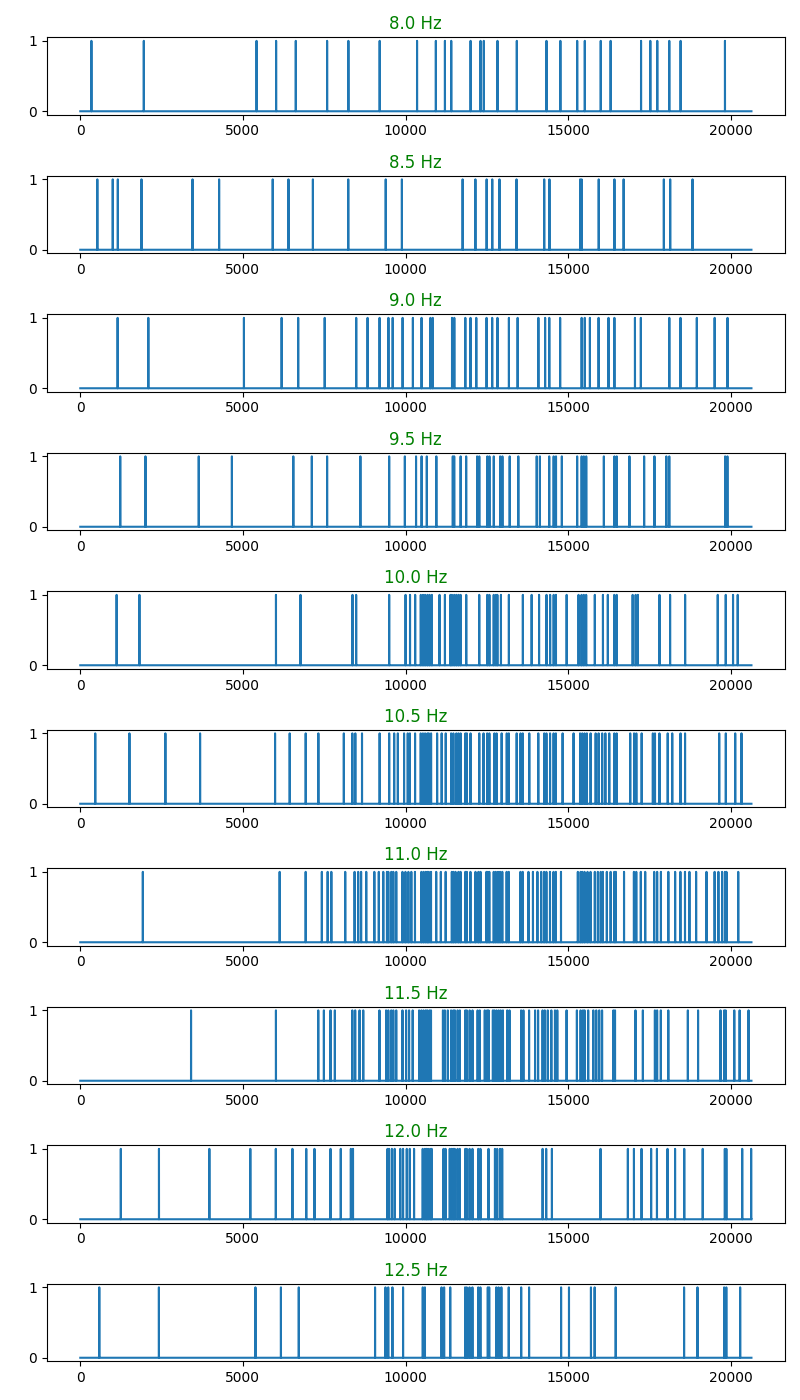

In [165]:
import numpy as np
import pandas as pd


class RFLayer:
    def __init__(self, frequenzen, decays, delta_t):
        self.frequenzen = frequenzen
        self.w = 2 * np.pi * frequenzen
        self.rotation = np.exp(self.w*delta_t*1j)
        self.decay = np.full(self.frequenzen.shape, fill_value=decays)
        self.threshold = 360
        self.s_previous = np.full(self.frequenzen.shape, fill_value=(0 + 0j))
        self.s_now = np.full(self.frequenzen.shape, fill_value=(0 + 0j))
        self.spike =  np.full(self.frequenzen.shape, fill_value=0)

    def update(self, i_synaptic):
        self.s_previous = self.s_now
        self.s_now = self.decay * self.rotation * self.s_previous + i_synaptic

    
    def get_strongest(self):
        return (np.max(self.s_now), np.argmax(self.s_now))


    def dospike(self):
        for i in range(len(self.frequenzen)):

            if ((self.s_previous[i].imag > 0 and self.s_now[i].imag <= 0) or (self.s_previous[i].imag < 0 and self.s_now[i].imag >= 0)) and \
                        self.s_now[i].real >= self.threshold:
                print(f"Spike! {self.s_now[i]}")
                self.s_now[i] = 0.01 * self.s_now[i] / np.abs(self.s_now[i])
                print(f"DANACH! {self.s_now[i]}")
                self.spike[i] = 1
            else:
                self.spike[i] = 0


frequenzen = np.arange(8, 13, 0.5)
print(frequenzen)

ABTASTRATE = 250
delta_t = 1/ABTASTRATE # Zeitschtitt der Simulation
decay = 1

layer1 = RFLayer(frequenzen, decay, delta_t)


augen_zu = pd.read_csv('../data/sanity-checks/gel augen zu besser/augen_zu.csv')
#eeg_7 = augen_zu[' EEG 8'].to_numpy()

eeg_7 = augen_zu[' EEG 8'].to_numpy()
#print(eeg_7.shape)
eeg_7 = np.trim_zeros(eeg_7)

history = np.zeros((len(eeg_7), len(frequenzen) ),
                   dtype=np.complex64)

spikes = np.zeros(shape=(len(eeg_7), len(frequenzen)))
for i in range(len(eeg_7)):
    layer1.update(eeg_7[i])
    layer1.dospike()
    spikes[i, :] = layer1.spike
    history[i] = np.where(layer1.spike == 0, layer1.s_now, 0)
   # print(layer1.s_now)
    layer1.get_strongest()
#print(history)   
#TODO NEXT: fuer jedes Channel visualisieren

import matplotlib.pyplot as plt

print(history.shape)
fig, axs = plt.subplots(len(frequenzen), 1,  figsize=(8, 1.4 * len(frequenzen)))
for i in range(len(axs)):
  #axs[i].plot(np.abs(history[:,i])) 
  axs[i].plot(spikes[:,i]) 
  axs[i].set_title(f"{frequenzen[i]} Hz", color="green")
  print(history[i])
  #axs[i].set_ylim(400)
fig.tight_layout() 

    

Das scheint in die richtige Richtung zu gehen, ABER:
- DC Offset wurde entfernt (Verarbeitung auf bereinigsten Daten) - weniger interessant fuer Echtzeit-Anwendungen

JETZT WILL ICH:
- fuer bereinigte Daten die Drehung auf der komplexen Ebene visualisieren - zB nur fuer 11 Hz, und zwar in 3D sodass ich diese Abbildung routueren kann


[ 8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5]
Spike! (3566.828048935643+126.32085762699036j)
DANACH! (0.00999373461898542+0.00035393271294462673j)
Spike! (3664.8529686345128+132.4345274048628j)
DANACH! (0.00999347719702372+0.0003611281110172955j)
Spike! (3639.005799626368+55.612683077335475j)
DANACH! (0.009998832448243877+0.00015280599446823036j)
Spike! (3632.7178870887687+33.87211058342405j)
DANACH! (0.009999565326804783+9.32377335822081e-05j)
Spike! (3739.4707104181907+309.48823869394084j)
DANACH! (0.009965926720706593+0.0008248057938123117j)
Spike! (3562.3026048285815+369.4853891805829j)
DANACH! (0.009946639981585874+0.001031674889060204j)
Spike! (3617.7713191010444+138.85388665186946j)
DANACH! (0.009992642600049928+0.0003835281836677144j)
Spike! (3563.9404004093244+264.3629689314479j)
DANACH! (0.009972601758710372+0.0007397392528227632j)
Spike! (3765.2305852617897+316.1801682943169j)
DANACH! (0.009964927506249135+0.000836791368979984j)
Spike! (3587.5265740256486+170.523443848

c:\Users\Dascha\Desktop\unicorn-hybrid-black-new\.mi-bci\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Dascha\Desktop\unicorn-hybrid-black-new\.mi-bci\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


'for i in range(len(axs)):\n  axs[i].plot(np.abs(history[:,i])) \n  axs[i].set_title(f"{frequenzen[i]} Hz", color="green")\n  print(history[i])\n  #axs[i].set_ylim(400)\nfig.tight_layout() '

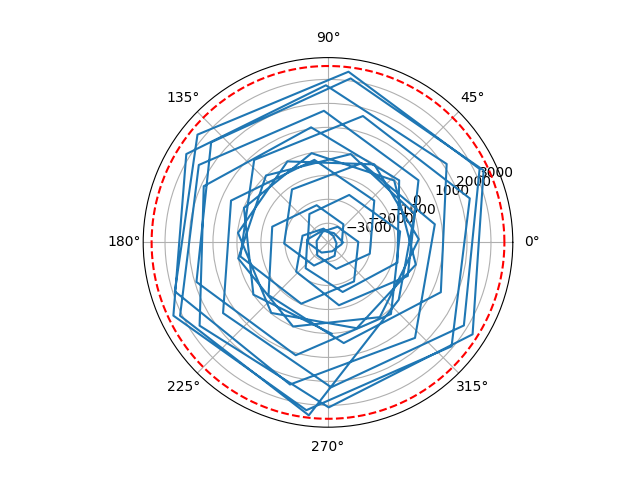

In [137]:
import numpy as np
import pandas as pd


class RFLayer:
    def __init__(self, frequenzen, decays, delta_t):
        self.frequenzen = frequenzen
        self.w = 2 * np.pi * frequenzen
        self.rotation = np.exp(self.w*delta_t*1j)
        self.decay = np.full(self.frequenzen.shape, fill_value=decays)
        self.threshold = 3560
        self.s_previous = np.full(self.frequenzen.shape, fill_value=(0 + 0j))
        self.s_now = np.full(self.frequenzen.shape, fill_value=(0 + 0j))
        self.spike =  np.full(self.frequenzen.shape, fill_value=0)

    def update(self, i_synaptic):
        self.s_previous = self.s_now
        self.s_now = self.decay * self.rotation * self.s_previous + i_synaptic

    
    def get_strongest(self):
        return (np.max(self.s_now), np.argmax(self.s_now))


    def dospike(self):
        for i in range(len(self.frequenzen)):

            if ((self.s_previous[i].imag > 0 and self.s_now[i].imag <= 0) or (self.s_previous[i].imag < 0 and self.s_now[i].imag >= 0)) and \
                        self.s_now[i].real >= self.threshold:
                print(f"Spike! {self.s_now[i]}")
                self.s_now[i] = 0.01 * self.s_now[i] / np.abs(self.s_now[i])
                print(f"DANACH! {self.s_now[i]}")
                self.spike[i] = 1
            else:
                self.spike[i] = 0


frequenzen = np.arange(8, 13, 0.5)
print(frequenzen)

ABTASTRATE = 250
delta_t = 1/ABTASTRATE # Zeitschtitt der Simulation
decay = 1    

layer1 = RFLayer(frequenzen, decay, delta_t)


augen_zu = pd.read_csv('../data/sanity-checks/gel augen zu besser/augen_zu.csv')
#eeg_7 = augen_zu[' EEG 8'].to_numpy()

eeg_7 = augen_zu[' EEG 8'].to_numpy()
#print(eeg_7.shape)
eeg_7 = np.trim_zeros(eeg_7)

history = np.zeros((len(eeg_7), len(frequenzen) ),
                   dtype=np.complex64)


#nur fuer 11Hz: index 6
for i in range(len(eeg_7)):
    layer1.update(eeg_7[i])
    layer1.dospike()
    history[i] = layer1.s_now
 
#TODO NEXT: fuer jedes Channel visualisieren
# ! threshold = 3560 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, subplot_kw={'projection':'polar'})
ax.plot(history[9300:9400,6])

theta = np.linspace(0, 2 * np.pi, 500)
r = np.full_like(theta, 3560)
ax.plot(theta, r, color="red", linestyle="--", linewidth=1.5, label="r = 3560")

"""for i in range(len(axs)):
  axs[i].plot(np.abs(history[:,i])) 
  axs[i].set_title(f"{frequenzen[i]} Hz", color="green")
  print(history[i])
  #axs[i].set_ylim(400)
fig.tight_layout() """

    

c:\Users\Dascha\Desktop\unicorn-hybrid-black-new\.mi-bci\lib\site-packages\numpy\ma\core.py:2892: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


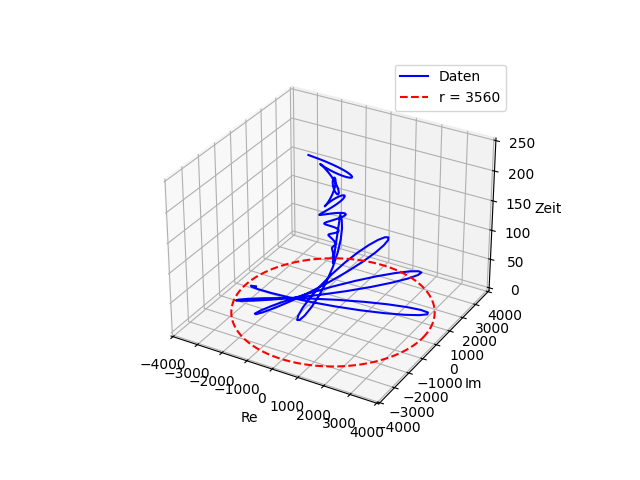

In [138]:
import matplotlib.pyplot as plt
import numpy as np

# Interaktives Backend aktivieren (WICHTIG für .ipynb)
%matplotlib widget

# Daten vorbereiten
data_r = history[9300:9550, 6]
theta_data = np.linspace(0, 2 * np.pi, len(data_r))
z_data = np.arange(len(data_r))

# Umrechnung Polar -> Kartesisch
x_data = data_r * np.cos(theta_data)
y_data = data_r * np.sin(theta_data)

# Kreis umrechnen
theta_circle = np.linspace(0, 2 * np.pi, 500)
x_circle = 3560 * np.cos(theta_circle)
y_circle = 3560 * np.sin(theta_circle)
z_circle = np.zeros_like(theta_circle)

# 3D Plot erstellen
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_data, y_data, z_data, label='Daten', color='blue')
ax.plot(x_circle, y_circle, z_circle, label='r = 3560', color='red', linestyle='--')

ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_zlabel('Zeit')
ax.legend()

plt.show()

Scheiss drauf wie schnell ich vorankomme!

TODO: vom jedem Wert den vorherigen Wert abziehen (quasi DC Offset entfernen)

[ 8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5]
Spike! (406587.96693651134+38339.30616511017j)
DANACH! (0.009955836343883275+0.0009387878854208057j)
Spike! (420446.40494698676+45876.67946312594j)
DANACH! (0.009940996785983649+0.0010847040615130023j)
Spike! (399761.26715757063+106352.65984168576j)
DANACH! (0.009663854428618267+0.00257097599803559j)
Spike! (436666.6547226211+32179.415652815245j)
DANACH! (0.009972956571668934+0.0007349402830199318j)
Spike! (416548.0592561079+100579.28260432262j)
DANACH! (0.009720645346423865+0.00234713741588516j)
Spike! (437842.875782884+72409.28849019931j)
DANACH! (0.009865994261589276+0.001631611850376019j)
Spike! (459168.3976864821+18968.403661022894j)
DANACH! (0.009991478183707405+0.00041275138340045536j)
Spike! (438277.0147053345+102236.29048671744j)
DANACH! (0.009738551457278756+0.0022716988167302992j)
Spike! (465076.0859511002+32029.43328863635j)
DANACH! (0.009976369170896534+0.0006870648921209768j)
Spike! (471903.310378033+33623.95851000321j)


c:\Users\Dascha\Desktop\unicorn-hybrid-black-new\.mi-bci\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Dascha\Desktop\unicorn-hybrid-black-new\.mi-bci\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


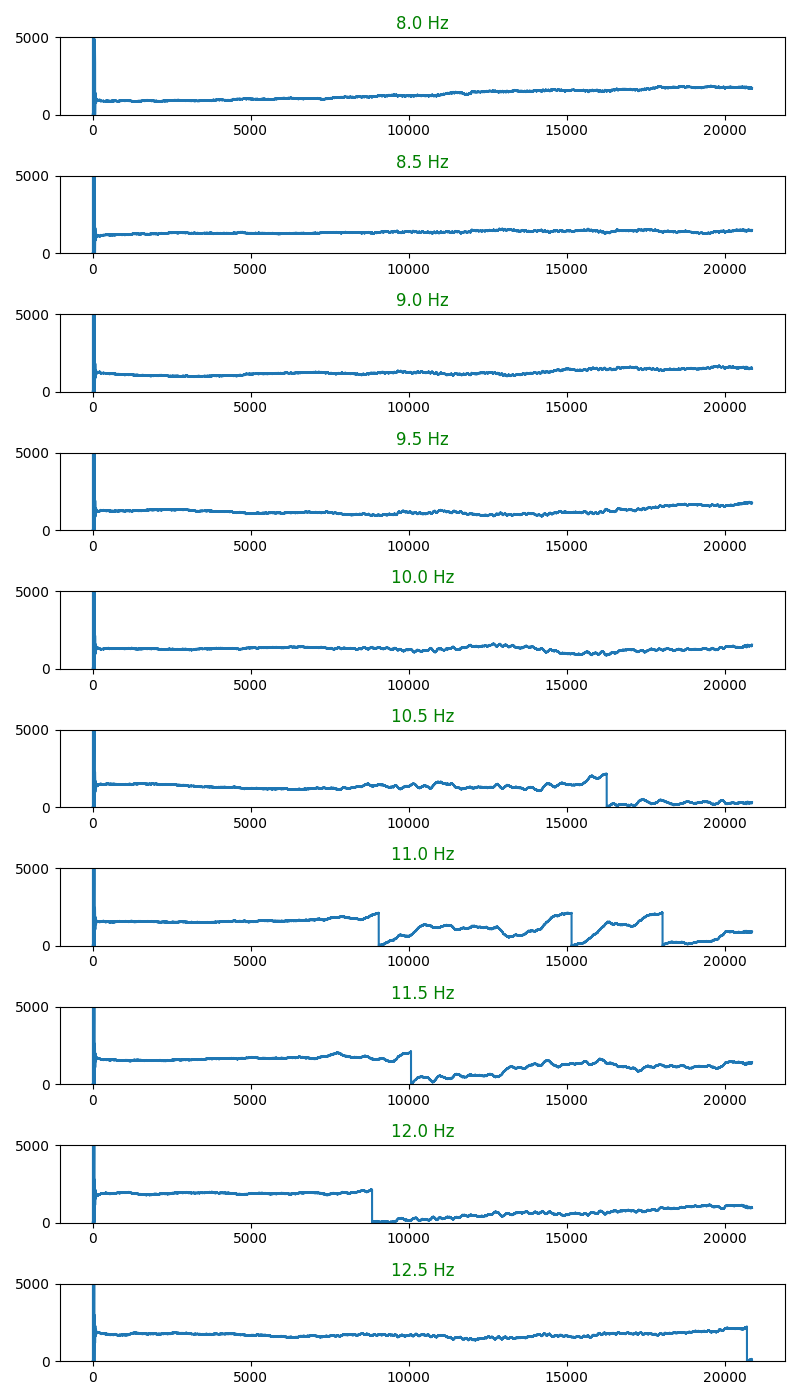

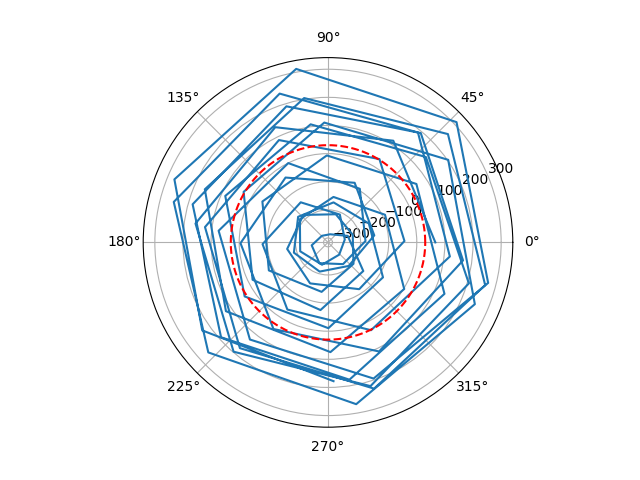

In [153]:
import numpy as np
import pandas as pd


class RFLayer:

    def __init__(self, frequenzen, decays, delta_t, baseline_decay=0.999):
        self.frequenzen = frequenzen
        self.w = 2 * np.pi * frequenzen
        self.rotation = np.exp(1j * self.w * delta_t)
        self.decay = np.full(self.frequenzen.shape, fill_value=decays)
        self.threshold = 2100

        self.s_previous = np.zeros(self.frequenzen.shape, dtype=np.complex128)
        self.s_now = np.zeros(self.frequenzen.shape, dtype=np.complex128)
        self.spike = np.zeros(self.frequenzen.shape, dtype=np.int32)
        self.baseline = np.zeros(self.frequenzen.shape, dtype=np.int32) 

    def set_first_baseline(self, first_datapoint):
        self.baseline = first_datapoint
        
    def update(self, i_synaptic):

        self.s_previous = self.s_now 
        self.s_now = self.decay * self.rotation * self.s_previous + i_synaptic - self.baseline
        self.baseline = i_synaptic
        

    def dospike(self):
        for i in range(len(self.frequenzen)):

            if ((self.s_previous[i].imag > 0 and self.s_now[i].imag <= 0) or (self.s_previous[i].imag < 0 and self.s_now[i].imag >= 0)) and \
                        self.s_now[i].real >= self.threshold:
                print(f"Spike! {self.s_now[i]}")
                self.s_now[i] = 0.01 * self.s_now[i] / np.abs(self.s_now[i]) #WAS PASSIERT HIER??????? 
                # phase soll bleiben, nur die Amplitude soll gehen!
                print(f"DANACH! {self.s_now[i]}")
                self.spike[i] = 1
            else:
                self.spike[i] = 0

frequenzen = np.arange(8, 13, 0.5)
print(frequenzen)

ABTASTRATE = 250
delta_t = 1/ABTASTRATE # Zeitschtitt der Simulation
decay = 1  

layer1 = RFLayer(frequenzen, decay, delta_t)


augen_zu = pd.read_csv('../data/sanity-checks/gel augen zu besser/augen-zu-raw.csv')
#eeg_7 = augen_zu[' EEG 8'].to_numpy()

eeg_7 = augen_zu[' EEG 8'].to_numpy()
#print(eeg_7.shape)
eeg_7 = np.trim_zeros(eeg_7)

history = np.zeros((len(eeg_7), len(frequenzen) ),
                   dtype=np.complex64)

#print(eeg_7.shape)
for i in range(len(eeg_7)):
    if i == 0:
        layer1.set_first_baseline(eeg_7[i])
    else:
        layer1.update(eeg_7[i])
        layer1.dospike()
        history[i] = np.where(layer1.spike == 0, layer1.s_now, 0) # FUELLE ICH DAS RICHTTIG?
       
   # print(layer1.s_now)
    #layer1.get_strongest()
#print(history)   
#TODO NEXT: fuer jedes Channel visualisieren

import matplotlib.pyplot as plt

print(history.shape)
fig, axs = plt.subplots(len(frequenzen), 1,  figsize=(8, 1.4 * len(frequenzen)))
for i in range(len(axs)):
  axs[i].plot(np.abs(history[:,i])) 
  
  #axs[i].plot(np.abs(history[0:20,i])) 
  axs[i].set_title(f"{frequenzen[i]} Hz", color="green")
  axs[i].set_ylim(-10,5000)
  #axs[i].set_xlim(0,1000)
                  #axs[i].set_xticks(np.arange(0,100,10))
  #axs[i].set_xlim(39)
fig.tight_layout() 

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, subplot_kw={'projection':'polar'})
ax.plot(history[9300:9400,6])

theta = np.linspace(0, 2 * np.pi, 2500)
r = np.full_like(theta, 30)
ax.plot(theta, r, color="red", linestyle="--", linewidth=1.5, label="r = 3560")

#WATAFUCKS:
# - wieso feuern alle Frequenzen exakt gleich
# - wenn ich bei diesem Versuch wo alles so aussieht als ob Neurone richtig feuern wuerden, decay auf etwas anderes als 1 
# setze funktioniert es nicht mehr 

                

![WARUM SIEHT ES SO KOMISCH AUS](../screenshots/rf_neuron.png)